# Hong Kong Trade & Distribution Performance & Business Efficiency

**Project type:** Business EDA / Business Intelligence  
**Tools:** Python + Tableau  
**Dataset:** Hong Kong Census & Statistics Department business-performance data  
**Period:** 2015–2024

---

## The PACE framework will be adopted in this analysis prject

> **P — PLAN → A — ANALYZE → C — CONSTRUCT → E — EVALUATE**

---

# 0. PLAN — Business Problem

### Business context

Hong Kong's import/export, wholesale and retail sectors contain businesses of very different sizes and business models. This dataset provides ten years of aggregated business statistics across industry categories and company-size groups.

### Primary business question

> **How have Hong Kong trading businesses evolved from 2015–2024, and which combinations of trade activity, product category and company size show materially different performance or efficiency patterns?**

### Intended stakeholder

Assume the audience is a **business strategy / economic research team** that wants to understand structural changes in Hong Kong trading businesses.

### Secondary questions

1. How have total receipts, persons engaged and industry value added changed over time?
2. How do import/export, wholesale and retail compare?
3. Within each trade activity, how do product categories differ?
4. How does company size relate to receipts and value added per person engaged?
5. Which segments experienced the largest changes during the COVID/recovery period?
6. Do cost structures differ across trade activities and company sizes?
7. Are there segments where receipts increased but value added did not increase at the same rate?

### Important

Do **not** combine parent categories with their children. The source has an industry hierarchy.


# 0.1 PLAN — Understand the Industry Hierarchy

The source category selector shows:

```text
Grand Total
│
├── Import/export trade
│   ├── Food, alcoholic drinks and tobacco
│   ├── Clothing, footwear and allied products
│   └── Other import/export trade
│
├── Wholesale trade
│   ├── Food, alcoholic drinks and tobacco
│   ├── Clothing, footwear and allied products
│   └── Other wholesale trade
│
└── Retail trade
    ├── Food, alcoholic drinks and tobacco
    ├── Fuel
    ├── Clothing, footwear and allied products
    ├── Transport equipment
    └── Other retail trade
```

### Key interpretation

The three appearances of **Food, alcoholic drinks and tobacco** are NOT duplicates:

- Import/export → Food
- Wholesale → Food
- Retail → Food

They represent different business activities.

Likewise, **Other import/export trade** is a child of Import/export trade. It should not be merged into the parent.

### Recommended analytical dimensions

| Dimension | Example |
|---|---|
| `trade_activity` | Import/export trade |
| `product_category` | Food, alcoholic drinks and tobacco |
| `company_size` | 10–49 |
| `year` | 2024 |

Keep the parent relationship throughout the analysis.


# 0.2 PLAN — Data Grain

Write this sentence yourself before continuing:

> **One row represents ________________________________________________.**

Expected answer:

> **One observation represents one industry category × one company-size group × one year, with business-performance measures for that combination.**

### Company-size groups

- `<10`
- `10–49`
- `50–99`
- `100–199`
- `200–499`
- `≥500`

### Core measures

1. Number of companies
2. Number of persons engaged
3. Total receipts (HK$ million)
4. Compensation of employees (HK$ million)
5. Operating expenses (HK$ million)
6. Cost of goods sold (HK$ million)
7. Industry value added (HK$ million)


# 0.3 PLAN — Data Limitations

### COVID / subsidy caveat

The source notes that **2021–2022 figures include subsidies related to anti-epidemic measures**.

Therefore:
- do not automatically interpret 2021–2022 growth as underlying business growth;
- annotate this period in the final dashboard;
- distinguish reported financial performance from underlying operating performance.

### Confidential values

The dataset may use `*` for suppressed/confidential values.

> `*` is **not zero**.

Treat these as missing values (`NaN`).

### Grand Total

Keep it in the raw data for validation, but do not mix it into ordinary segment calculations.

### Parent/child categories

Never sum a parent row together with its child rows.


# 1. Environment Setup

We deliberately use **Python + Tableau only** for this project. SQL is excluded from this version so that the project stays focused.


In [511]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")


# 2. Load the Raw Data

Put the downloaded CSV in the same folder as this notebook.

**Guiding question:** What exactly did the source give us?

Do not clean the data before preserving the raw copy.


In [512]:
DATA_PATH ="C:/Users/Ed/Desktop/DA/hk retail industry pj/raw.xlsx"


from pathlib import Path
import numpy as np
import pandas as pd

RAW   = Path(DATA_PATH)
SHEET = "Table 630-76002_en"

raw = pd.read_excel(RAW, sheet_name=SHEET, header=None, engine="openpyxl")
print(raw.shape)   

(114, 72)


# 3. Inspect the Multi-level Header

### Decision Gate 1

Inspect the output above and answer:

1. Which row contains the years?
2. Which row contains the seven measures?
3. Which columns identify industry/category?
4. Which column identifies company size?
5. Which header cells are blank because the source uses merged cells?

Set `HEADER_ROWS` only after inspecting the raw file.


In [513]:
raw.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,Table 630-76002 : Principal statistics for all...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Year,NaN,2015,2015,2015,2015,2015,2015,2015,2016,2016,2016,2016,2016,2016,2016,2017,2017,2017,2017,2017,2017,2017,2018,2018,2018,2018,2018,2018,2018,2019,2019,2019,2019,2019,2019,2019,2020,2020,2020,2020,2020,2020,2020,2021,2021,2021,2021,2021,2021,2021,2022,2022,2022,2022,2022,2022,2022,2023,2023,2023,2023,2023,2023,2023,2024,2024,2024,2024,2024,2024,2024
3,,,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
4,NaN,NaN,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million
5,Industry Grouping,Number of persons engaged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Import/export trade,< 10,70481,226453,1645381,61651,101888,1383801,155615,71488,224580,1954602,64510,101065,1730432,134393,69961,211700,1619941,58771,113076,1361571,169819,69184,200884,1704492,57023,102467,1489599,116967,65780,

In [514]:
# Change this after inspecting raw.head(15).
HEADER_ROWS = 4

display(raw.iloc[:HEADER_ROWS + 2, :20])


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,Table 630-76002 : Principal statistics for all...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Year,NaN,2015,2015,2015,2015,2015,2015,2015,2016,2016,2016,2016,2016,2016,2016,2017,2017,2017,2017
3,,,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees
4,NaN,NaN,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million,HK$ million,HK$ million,HK$ million,Number,Number,HK$ million,HK$ million
5,Industry Grouping,Number of persons engaged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4. Reconstruct the Header

The source is designed for human viewing, so years and measures are spread across multiple header rows.

We convert the multi-row header into a single column name for every data column.


In [515]:
df = raw.drop(index=[0, 1, 4]).reset_index(drop=True)
df.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,Year,NaN,2015,2015,2015,2015,2015,2015,2015,2016,2016,2016,2016,2016,2016,2016,2017,2017,2017,2017,2017,2017,2017,2018,2018,2018,2018,2018,2018,2018,2019,2019,2019,2019,2019,2019,2019,2020,2020,2020,2020,2020,2020,2020,2021,2021,2021,2021,2021,2021,2021,2022,2022,2022,2022,2022,2022,2022,2023,2023,2023,2023,2023,2023,2023,2024,2024,2024,2024,2024,2024,2024
1,,,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
2,Industry Grouping,Number of persons engaged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Import/export trade,< 10,70481,226453,1645381,61651,101888,1383801,155615,71488,224580,1954602,64510,101065,1730432,134393,69961,211700,1619941,58771,113076,1361571,169819,69184,200884,1704492,57023,102467,1489599,116967,65780,191996,1507956,56893,88397,1291530,132527,66853,192164,1530251,54946,85273,1331751,103087,67149,189935,1536206,60188,94942,1286077,154188,70429,185966,1384663,62257,106178,1089693,165902,66906,174850,1235357,55350,86585,984252,150671,62048,167865,1338270,56377,117491,1039295,149227
4,Import/export trade,10 - 49,9195,155526,1415865,56875,86202,1183404,140246,9077,153085,1057691,57684,89867,813343,148688,7760,142206,1312797,57964,76082,1106535,120229,8602,153525,1204100,63855,71048,954452,176044,8160,155497,1229895,60345,86010,996775,141034,6679,125796,1128554,56675,87860,884625,150594,6619,118961,1594557,56179,101525,1344552,140078,5693,107989,1582094,53818,92728,1273351,179401,7509,117746,1597686,57979,109710,1265319,172881,6680,112053,1503243,57963,86685,1192534,193359


In [516]:
df.tail(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
91,Transport equipment,≥ 500,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,1,529,*,*,*,*,*,1,578,*,*,*,*,*,1,783,*,*,*,*,*,1,739,*,*,*,*,*,1,749,*,*,*,*,*,2,1236,*,*,*,*,*,2,1240,*,*,*,*,*
92,Transport equipment,Total,965,4701,23176,1268,1876,18746,2490,891,4625,21523,1310,2099,16920,2525,857,4567,22335,1377,2115,17756,2464,931,4751,24106,1511,2267,19288,2583,950,4643,22113,1466,2048,17604,2433,884,4592,20877,1372,1758,17085,1882,911,4707,22984,1499,1964,18575,2417,844,5513,24396,1737,2285,19353,2762,1058,5624,25465,1766,2693,19741,2946,888,5249,19928,1784,2557,14590,2594
93,Other retail trade,< 10,23661,48228,46877,3956,9568,30034,7283,22866,47611,49554,4525,9728,33468,6416,22634,45512,48947,4332,10115,32604,6329,23185,49895,54625,5251,11247,36738,6651,22486,47616,43577,5118,9349,27996,6250,22690,46532,38945,5032,8912,24098,4047,23368,42534,38276,4068,8563,25210,4495,24906,48939,37229,4348,8938,23928,4160,25834,52081,56901,6779,12413,39296,5456,25045,48353,56221,7324,11281,35970,7671
94,Other retail trade,10 - 49,886,17205,37170,3889,7065,26116,4060,767,14381,36139,3462,5879,25260,5001,1019,17448,41142,4354,6499,28534,6186,708,14196,44003,4441,8350,28828,6902,794,13879,36530,3998,6920,24082,5473,710,12915,25571,3382,5260,16119,3431,892,16134,33747,4536,6301,21923,5097,723,13622,30549,3847,5921,19273,5106,597,10377,38557,3586,6169,22954,7986,953,15302,41084,4838,7650,25489,7716
95,Other retail trade,50 - 99,184,12231,47374,3733,9100,25852,12258,210,12495,29843,3039,6859,15193,7878,159,10927,34416,2949,8519,19881,5999,151,10696,34131,3287,8005,20014,5916,141,9778,29391,2751,6793,18254,4118,125,8789,23744,2957,6170,14719,1927,117,8625,29601,3487,6483,18538,3570,149,10067,27187,4378,7185,17386,1848,103,7436,28471,2934,6880,18229,3003,108,7664,30382,3013,7030,19275,3189
96,Other retail trade,100 - 199,66,8901,25866,2324,8222,14382,3244,64,8738,25197,2367,7868,13937,3390,60,8384,22671,2365,6581,12706,3350,62,8231,20218,2374,6097,10421,3771,51,6783,16869,2171,5827,8234,2919,52,7386,24384,2367,5594,15830,2436,103,12944,23714,3382,5841,13251,3727,54,7460,21611,2513,6806,12424,2136,56,7879,26364,2951,7658,15733,2464,51,6909,20491,2610,6247,10962,2858
97,Other retail trade,200 - 499,40,12525,38387,3947,10214,18599,8384,41,12139,35589,4212,9855,16840,7629,41,12752,42664,4422,10957,21543,8568,48,14621,55499,4605,13407,28314,10829,48,14149,49814,4678,11172,26484,9022,39,11315,27228,3692,8250,11610,3880,34,9825,33709,3128,7951,14328,4414,31,9272,49516,3177,7015,24568,2971,31,8933,43419,3316,8907,29411,3398,33,10092,45487,3673,8690,24310,5259
98,Other retail trade,≥ 500,30,43292,165592,11912,28122,115817,20899,31,41279,150156,11302,27793,98002,18294,31,40488,154119,11898,28586,101218,20759,32,42296,171372,13325,29685,117301,20601,33,42678,135307,12852,26735,89105,15000,29,38080,99092,10624,19415,64014,9388,30,35835,102820,10134,20765,71643,8954,27,33813,100696,9650,17448,68503,12646,30,36849,134073,10240,26837,82228,21803,28,33367,108278,9429,26654,68987,12155
99,Other retail trade,Total,24866,142381,361266,29761,72291,230800,56127,23979,136643,326478,28906,67983,202701,48608,23943,135511,343959,30321,71256,216485,51191,24186,139936,379848,33283,76792,241616,54670,23553,134883,311489,31568,66795,194155,42783,23645,125017,238964,28055,53603,146389,25109,24544,125896,261866,28736,55904,164893,30258,25890,123173,266789,27913,53312,166082,28867,26652,123555,327785,29805,68863,207851,44111,26218,121687,301943,30887,67552,184993,38848
100,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [517]:
df = df.iloc[:100].reset_index(drop=True)
df.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
95,Other retail trade,50 - 99,184,12231,47374,3733,9100,25852,12258,210,12495,29843,3039,6859,15193,7878,159,10927,34416,2949,8519,19881,5999,151,10696,34131,3287,8005,20014,5916,141,9778,29391,2751,6793,18254,4118,125,8789,23744,2957,6170,14719,1927,117,8625,29601,3487,6483,18538,3570,149,10067,27187,4378,7185,17386,1848,103,7436,28471,2934,6880,18229,3003,108,7664,30382,3013,7030,19275,3189
96,Other retail trade,100 - 199,66,8901,25866,2324,8222,14382,3244,64,8738,25197,2367,7868,13937,3390,60,8384,22671,2365,6581,12706,3350,62,8231,20218,2374,6097,10421,3771,51,6783,16869,2171,5827,8234,2919,52,7386,24384,2367,5594,15830,2436,103,12944,23714,3382,5841,13251,3727,54,7460,21611,2513,6806,12424,2136,56,7879,26364,2951,7658,15733,2464,51,6909,20491,2610,6247,10962,2858
97,Other retail trade,200 - 499,40,12525,38387,3947,10214,18599,8384,41,12139,35589,4212,9855,16840,7629,41,12752,42664,4422,10957,21543,8568,48,14621,55499,4605,13407,28314,10829,48,14149,49814,4678,11172,26484,9022,39,11315,27228,3692,8250,11610,3880,34,9825,33709,3128,7951,14328,4414,31,9272,49516,3177,7015,24568,2971,31,8933,43419,3316,8907,29411,3398,33,10092,45487,3673,8690,24310,5259
98,Other retail trade,≥ 500,30,43292,165592,11912,28122,115817,20899,31,41279,150156,11302,27793,98002,18294,31,40488,154119,11898,28586,101218,20759,32,42296,171372,13325,29685,117301,20601,33,42678,135307,12852,26735,89105,15000,29,38080,99092,10624,19415,64014,9388,30,35835,102820,10134,20765,71643,8954,27,33813,100696,9650,17448,68503,12646,30,36849,134073,10240,26837,82228,21803,28,33367,108278,9429,26654,68987,12155
99,Other retail trade,Total,24866,142381,361266,29761,72291,230800,56127,23979,136643,326478,28906,67983,202701,48608,23943,135511,343959,30321,71256,216485,51191,24186,139936,379848,33283,76792,241616,54670,23553,134883,311489,31568,66795,194155,42783,23645,125017,238964,28055,53603,146389,25109,24544,125896,261866,28736,55904,164893,30258,25890,123173,266789,27913,53312,166082,28867,26652,123555,327785,29805,68863,207851,44111,26218,121687,301943,30887,67552,184993,38848


In [518]:
year_row=df.iloc[0,:].tolist()
del year_row[0:2]
year_row

[2015,
 2015,
 2015,
 2015,
 2015,
 2015,
 2015,
 2016,
 2016,
 2016,
 2016,
 2016,
 2016,
 2016,
 2017,
 2017,
 2017,
 2017,
 2017,
 2017,
 2017,
 2018,
 2018,
 2018,
 2018,
 2018,
 2018,
 2018,
 2019,
 2019,
 2019,
 2019,
 2019,
 2019,
 2019,
 2020,
 2020,
 2020,
 2020,
 2020,
 2020,
 2020,
 2021,
 2021,
 2021,
 2021,
 2021,
 2021,
 2021,
 2022,
 2022,
 2022,
 2022,
 2022,
 2022,
 2022,
 2023,
 2023,
 2023,
 2023,
 2023,
 2023,
 2023,
 2024,
 2024,
 2024,
 2024,
 2024,
 2024,
 2024]

In [519]:
id_row=df.iloc[2,:2].tolist()
id_row.insert(0,'year')
id_row[2]='scale_band'
id_row

['year', 'Industry Grouping', 'scale_band']

In [520]:
measure_row=df.iloc[1,2:9].tolist()
measure_row

['Number of companies',
 'Number of persons engaged',
 'Total receipts (1)',
 'Compensation of employees',
 'Operating expenses',
 'Cost of goods sold',
 'Industry value added']

In [521]:
col_list=id_row+measure_row
col_list

['year',
 'Industry Grouping',
 'scale_band',
 'Number of companies',
 'Number of persons engaged',
 'Total receipts (1)',
 'Compensation of employees',
 'Operating expenses',
 'Cost of goods sold',
 'Industry value added']

In [522]:

years=sorted(list(set(year_row)))
years_list=[]
for i in years:
        years_list.extend([i]*97)
len(years_list)

970

In [523]:
df.iloc[3:,0].to_list()

['     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '          Food, alcoholic drinks and tobacco',
 '          Food, alcoholic drinks and tobacco',
 '          Food, alcoholic drinks and tobacco',
 '          Food, alcoholic drinks and tobacco',
 '          Food, alcoholic drinks and tobacco',
 '          Food, alcoholic drinks and tobacco',
 '          Food, alcoholic drinks and tobacco',
 '          Clothing, footwear and allied products',
 '          Clothing, footwear and allied products',
 '          Clothing, footwear and allied products',
 '          Clothing, footwear and allied products',
 '          Clothing, footwear and allied products',
 '          Clothing, footwear and allied products',
 '          Clothing, footwear and allied products',
 '          Other import/export trade',
 '          Other import/export trade',
 ' 

In [524]:
len(df)

100

In [525]:
Grouping=df.iloc[3:,0].to_list()
Grouping=Grouping*10

In [526]:
len(Grouping)

970

In [527]:
scale=df.iloc[3:,1].to_list()
scale=scale*10
len(scale)

970

In [528]:
df.iloc[3:,2]

3     70481
4      9195
5       580
6       167
7        70
      ...  
95      184
96       66
97       40
98       30
99    24866
Name: 2, Length: 97, dtype: object

In [529]:
col_list

['year',
 'Industry Grouping',
 'scale_band',
 'Number of companies',
 'Number of persons engaged',
 'Total receipts (1)',
 'Compensation of employees',
 'Operating expenses',
 'Cost of goods sold',
 'Industry value added']

In [530]:
col_list[5]='Total revenue'
col_list

['year',
 'Industry Grouping',
 'scale_band',
 'Number of companies',
 'Number of persons engaged',
 'Total revenue',
 'Compensation of employees',
 'Operating expenses',
 'Cost of goods sold',
 'Industry value added']

In [531]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,Year,NaN,2015,2015,2015,2015,2015,2015,2015,2016,2016,2016,2016,2016,2016,2016,2017,2017,2017,2017,2017,2017,2017,2018,2018,2018,2018,2018,2018,2018,2019,2019,2019,2019,2019,2019,2019,2020,2020,2020,2020,2020,2020,2020,2021,2021,2021,2021,2021,2021,2021,2022,2022,2022,2022,2022,2022,2022,2023,2023,2023,2023,2023,2023,2023,2024,2024,2024,2024,2024,2024,2024
1,,,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Number of companies,Number of persons engaged,Total receipts (1),Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
2,Industry Grouping,Number of persons engaged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Import/export trade,< 10,70481,226453,1645381,61651,101888,1383801,155615,71488,224580,1954602,64510,101065,1730432,134393,69961,211700,1619941,58771,113076,1361571,169819,69184,200884,1704492,57023,102467,1489599,116967,65780,191996,1507956,56893,88397,1291530,132527,66853,192164,1530251,54946,85273,1331751,103087,67149,189935,1536206,60188,94942,1286077,154188,70429,185966,1384663,62257,106178,1089693,165902,66906,174850,1235357,55350,86585,984252,150671,62048,167865,1338270,56377,117491,1039295,149227
4,Import/export trade,10 - 49,9195,155526,1415865,56875,86202,1183404,140246,9077,153085,1057691,57684,89867,813343,148688,7760,142206,1312797,57964,76082,1106535,120229,8602,153525,1204100,63855,71048,954452,176044,8160,155497,1229895,60345,86010,996775,141034,6679,125796,1128554,56675,87860,884625,150594,6619,118961,1594557,56179,101525,1344552,140078,5693,107989,1582094,53818,92728,1273351,179401,7509,117746,1597686,57979,109710,1265319,172881,6680,112053,1503243,57963,86685,1192534,193359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Other retail trade,50 - 99,184,12231,47374,3733,9100,25852,12258,210,12495,29843,3039,6859,15193,7878,159,10927,34416,2949,8519,19881,5999,151,10696,34131,3287,8005,20014,5916,141,9778,29391,2751,6793,18254,4118,125,8789,23744,2957,6170,14719,1927,117,8625,29601,3487,6483,18538,3570,149,10067,271

In [532]:
col_list

['year',
 'Industry Grouping',
 'scale_band',
 'Number of companies',
 'Number of persons engaged',
 'Total revenue',
 'Compensation of employees',
 'Operating expenses',
 'Cost of goods sold',
 'Industry value added']

In [533]:
Number_of_companies=[]
for i in range(10): # 10 times
    col_num = 2 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Number_of_companies.extend(ap)

In [534]:
Number_of_employee=[]
for i in range(10): # 10 times
    col_num = 3 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Number_of_employee.extend(ap)

In [535]:
Total_revenue=[]
for i in range(10): # 10 times
    col_num = 4 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Total_revenue.extend(ap)

In [536]:
Compensation_of_employees=[]
for i in range(10): # 10 times
    col_num = 5 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Compensation_of_employees.extend(ap)

In [537]:
Operating_expenses=[]
for i in range(10): # 10 times
    col_num = 6 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Operating_expenses.extend(ap)

In [538]:
Cost_of_goods_sold=[]
for i in range(10): # 10 times
    col_num = 7 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Cost_of_goods_sold.extend(ap)

In [539]:
Industry_value_added=[]
for i in range(10): # 10 times
    col_num = 8 + i * 7   # 2, 9, 16, 23, ... 65
    ap=df.iloc[3:,col_num].tolist()
    Industry_value_added.extend(ap)

In [540]:
col_list

['year',
 'Industry Grouping',
 'scale_band',
 'Number of companies',
 'Number of persons engaged',
 'Total revenue',
 'Compensation of employees',
 'Operating expenses',
 'Cost of goods sold',
 'Industry value added']

In [541]:
items_list=[years_list, Grouping , scale, Number_of_companies, Number_of_employee, Total_revenue, Compensation_of_employees, Operating_expenses,
Cost_of_goods_sold, Industry_value_added]

In [542]:
len(years_list)

970

In [543]:
df = pd.DataFrame(dict(zip(col_list,items_list)))
df.tail(10)

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
960,2024,Transport equipment,200 - 499,2,705,*,*,*,*,*
961,2024,Transport equipment,≥ 500,2,1240,*,*,*,*,*
962,2024,Transport equipment,Total,888,5249,19928,1784,2557,14590,2594
963,2024,Other retail trade,< 10,25045,48353,56221,7324,11281,35970,7671
964,2024,Other retail trade,10 - 49,953,15302,41084,4838,7650,25489,7716
965,2024,Other retail trade,50 - 99,108,7664,30382,3013,7030,19275,3189
966,2024,Other retail trade,100 - 199,51,6909,20491,2610,6247,10962,2858
967,2024,Other retail trade,200 - 499,33,10092,45487,3673,8690,24310,5259
968,2024,Other retail trade,≥ 500,28,33367,108278,9429,26654,68987,12155
969,2024,Other retail trade,Total,26218,121687,301943,30887,67552,184993,38848


## Decision Gate 2

Stop if the headers look wrong.

Typical problems:
- years are missing;
- measures are not attached to the correct year;
- industry/company-size columns are mixed into the year columns.

Fix `HEADER_ROWS` before continuing.


# 10. Data Quality — Missing Values (Data Cleaning)

### Questions

- Which measures contain missing values?
- Are missing values concentrated in large-company groups?
- Are they likely to be confidentiality suppression?
- Are there suspiciously large gaps?

Remember:

> Missing because of `*` ≠ zero.


In [544]:
df.head()

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
0,2015,Import/export trade,< 10,70481,226453,1645381,61651,101888,1383801,155615
1,2015,Import/export trade,10 - 49,9195,155526,1415865,56875,86202,1183404,140246
2,2015,Import/export trade,50 - 99,580,36486,343224,16128,27546,275352,39041
3,2015,Import/export trade,100 - 199,167,23220,274225,11263,31632,181734,52263
4,2015,Import/export trade,200 - 499,70,21105,211493,10607,20319,155359,25483


In [545]:
df.dtypes

year                          int64
Industry Grouping            object
scale_band                   object
Number of companies          object
Number of persons engaged    object
Total revenue                object
Compensation of employees    object
Operating expenses           object
Cost of goods sold           object
Industry value added         object
dtype: object

In [546]:
df[df['Number of companies']=='N.A.']

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
39,2015,"Food, alcoholic drinks and tobacco",200 - 499,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
45,2015,"Clothing, footwear and allied products",100 - 199,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
74,2015,Fuel,≥ 500,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
88,2015,Transport equipment,≥ 500,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
136,2016,"Food, alcoholic drinks and tobacco",200 - 499,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
142,2016,"Clothing, footwear and allied products",100 - 199,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
171,2016,Fuel,≥ 500,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
185,2016,Transport equipment,≥ 500,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
233,2017,"Food, alcoholic drinks and tobacco",200 - 499,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
239,2017,"Clothing, footwear and allied products",100 - 199,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.


In [547]:
df = df.replace("N.A.", np.nan)

C:\Users\Ed\AppData\Local\Temp\ipykernel_32816\3092409961.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("N.A.", np.nan)


In [548]:
df[df.eq("N.A.").any(axis=1)]

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added


In [549]:
df[df.eq("*").any(axis=1)]

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
11,2015,"Food, alcoholic drinks and tobacco",200 - 499,8.00,"2,108.00",*,*,*,*,*
12,2015,"Food, alcoholic drinks and tobacco",≥ 500,1.00,"1,005.00",*,*,*,*,*
18,2015,"Clothing, footwear and allied products",200 - 499,20.00,"6,092.00",*,*,*,*,*
19,2015,"Clothing, footwear and allied products",≥ 500,4.00,"3,792.00",*,*,*,*,*
32,2015,Wholesale trade,200 - 499,5.00,"1,515.00",*,*,*,*,*
...,...,...,...,...,...,...,...,...,...,...
946,2024,Fuel,200 - 499,2.00,781.00,*,*,*,*,*
958,2024,Transport equipment,50 - 99,9.00,494.00,*,*,*,*,*
959,2024,Transport equipment,100 - 199,3.00,404.00,*,*,*,*,*
960,2024,Transport equipment,200 - 499,2.00,705.00,*,*,*,*,*


In [550]:
df = df.replace("*", np.nan)

C:\Users\Ed\AppData\Local\Temp\ipykernel_32816\379430554.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("*", np.nan)


In [551]:
df[df.eq("*").any(axis=1)]

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added


In [552]:
df.duplicated().any()

np.False_

In [553]:
df.dtypes

year                           int64
Industry Grouping             object
scale_band                    object
Number of companies          float64
Number of persons engaged    float64
Total revenue                float64
Compensation of employees    float64
Operating expenses           float64
Cost of goods sold           float64
Industry value added         float64
dtype: object

In [554]:
df.loc[df['scale_band']=='Total']


,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
6,2015,Import/export trade,Total,"80,512.00","479,070.00","3,961,089.00","163,170.00","281,326.00","3,219,782.00","426,666.00"
13,2015,"Food, alcoholic drinks and tobacco",Total,"5,164.00","31,697.00","173,024.00","9,478.00","16,190.00","133,155.00","20,798.00"
20,2015,"Clothing, footwear and allied products",Total,"14,694.00","101,190.00","367,011.00","33,049.00","42,200.00","252,510.00","71,764.00"
27,2015,Other import/export trade,Total,"60,654.00","346,183.00","3,421,054.00","120,643.00","222,936.00","2,834,117.00","334,105.00"
34,2015,Wholesale trade,Total,"13,832.00","64,074.00","313,286.00","13,018.00","14,676.00","277,123.00","21,401.00"
...,...,...,...,...,...,...,...,...,...,...
941,2024,"Food, alcoholic drinks and tobacco",Total,"10,206.00","65,498.00","100,449.00","11,341.00","22,806.00","63,967.00","13,478.00"
948,2024,Fuel,Total,172.00,"3,203.00","5,744.00",638.00,337.00,"4,594.00",814.00
955,2024,"Clothing, footwear and allied products",Total,"6,046.00","40,718.00","61,098.00","9,282.00","18,396.00","25,140.00","13,205.00"
962,2024,Transport equipment,Total,888.00,"5,249.00","19,928.00","1,784.00","2,557.00","14,590.00","2,594.00"


In [555]:
df=df.drop(df.index[df['scale_band']=='Total']).reset_index(drop=True)

In [556]:
df.head(10)

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
0,2015,Import/export trade,< 10,"70,481.00","226,453.00","1,645,381.00","61,651.00","101,888.00","1,383,801.00","155,615.00"
1,2015,Import/export trade,10 - 49,"9,195.00","155,526.00","1,415,865.00","56,875.00","86,202.00","1,183,404.00","140,246.00"
2,2015,Import/export trade,50 - 99,580.00,"36,486.00","343,224.00","16,128.00","27,546.00","275,352.00","39,041.00"
3,2015,Import/export trade,100 - 199,167.00,"23,220.00","274,225.00","11,263.00","31,632.00","181,734.00","52,263.00"
4,2015,Import/export trade,200 - 499,70.00,"21,105.00","211,493.00","10,607.00","20,319.00","155,359.00","25,483.00"
5,2015,Import/export trade,≥ 500,19.00,"16,280.00","70,901.00","6,647.00","13,740.00","40,132.00","14,018.00"
6,2015,"Food, alcoholic drinks and tobacco",< 10,"4,569.00","12,962.00","65,319.00","2,484.00","3,962.00","54,418.00","7,145.00"
7,2015,"Food, alcoholic drinks and tobacco",10 - 49,512.00,"10,197.00","60,021.00","3,681.00","8,065.00","43,972.00","7,847.00"
8,2015,"Food, alcoholic drinks and tobacco",50 - 99,63.00,"3,855.00","16,156.00","1,181.00","1,477.00","12,294.00","2,436.00"
9,2015,"Food, alcoholic drinks and tobacco",100 - 199,11.00,"1,571.00","11,303.00",569.00,"1,078.00","8,790.00","1,157.00"


In [557]:
len(df)

830

In [558]:
df[df['year']==2023]

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
664,2023,Import/export trade,< 10,"66,906.00","174,850.00","1,235,357.00","55,350.00","86,585.00","984,252.00","150,671.00"
665,2023,Import/export trade,10 - 49,"7,509.00","117,746.00","1,597,686.00","57,979.00","109,710.00","1,265,319.00","172,881.00"
666,2023,Import/export trade,50 - 99,407.00,"26,956.00","664,620.00","15,537.00","39,912.00","543,693.00","67,408.00"
667,2023,Import/export trade,100 - 199,140.00,"19,537.00","366,817.00","11,765.00","26,714.00","315,495.00","19,965.00"
668,2023,Import/export trade,200 - 499,50.00,"13,882.00","273,854.00","9,049.00","28,414.00","192,740.00","33,816.00"
...,...,...,...,...,...,...,...,...,...,...
742,2023,Other retail trade,10 - 49,597.00,"10,377.00","38,557.00","3,586.00","6,169.00","22,954.00","7,986.00"
743,2023,Other retail trade,50 - 99,103.00,"7,436.00","28,471.00","2,934.00","6,880.00","18,229.00","3,003.00"
744,2023,Other retail trade,100 - 199,56.00,"7,879.00","26,364.00","2,951.00","7,658.00","15,733.00","2,464.00"
745,2023,Other retail trade,200 - 499,31.00,"8,933.00","43,419.00","3,316.00","8,907.00","29,411.00","3,398.00"


In [559]:
df[df['year']==2024]

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
747,2024,Import/export trade,< 10,"62,048.00","167,865.00","1,338,270.00","56,377.00","117,491.00","1,039,295.00","149,227.00"
748,2024,Import/export trade,10 - 49,"6,680.00","112,053.00","1,503,243.00","57,963.00","86,685.00","1,192,534.00","193,359.00"
749,2024,Import/export trade,50 - 99,389.00,"26,248.00","1,012,354.00","17,168.00","53,688.00","869,695.00","75,493.00"
750,2024,Import/export trade,100 - 199,132.00,"18,248.00","329,531.00","11,625.00","28,144.00","268,947.00","26,027.00"
751,2024,Import/export trade,200 - 499,51.00,"14,122.00","220,522.00","8,657.00","24,177.00","159,796.00","27,029.00"
...,...,...,...,...,...,...,...,...,...,...
825,2024,Other retail trade,10 - 49,953.00,"15,302.00","41,084.00","4,838.00","7,650.00","25,489.00","7,716.00"
826,2024,Other retail trade,50 - 99,108.00,"7,664.00","30,382.00","3,013.00","7,030.00","19,275.00","3,189.00"
827,2024,Other retail trade,100 - 199,51.00,"6,909.00","20,491.00","2,610.00","6,247.00","10,962.00","2,858.00"
828,2024,Other retail trade,200 - 499,33.00,"10,092.00","45,487.00","3,673.00","8,690.00","24,310.00","5,259.00"


In [560]:
len(df['Industry Grouping'].tolist())

830

In [561]:
Grouping_upd=df['Industry Grouping'].tolist()

In [562]:
Grouping_upd[46]

'          Other wholesale trade'

In [563]:

for i in range(len(df)):
    
    position = i % 83
    
    if position < 6:
        Grouping_upd[i]=Grouping_upd[i]
        
    elif position < 24:
        Grouping_upd[i]=Grouping_upd[i]+"_I/E"
        
    elif position < 30:
        Grouping_upd[i]=Grouping_upd[i]
         
    elif position < 47:
        Grouping_upd[i]=Grouping_upd[i]+"_W"
        
    elif position < 53:
        Grouping_upd[i]=Grouping_upd[i]
        
    else:
        Grouping_upd[i]=Grouping_upd[i]+"_R"

In [564]:
Grouping_upd[:85]

['     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '     Import/export trade',
 '          Food, alcoholic drinks and tobacco_I/E',
 '          Food, alcoholic drinks and tobacco_I/E',
 '          Food, alcoholic drinks and tobacco_I/E',
 '          Food, alcoholic drinks and tobacco_I/E',
 '          Food, alcoholic drinks and tobacco_I/E',
 '          Food, alcoholic drinks and tobacco_I/E',
 '          Clothing, footwear and allied products_I/E',
 '          Clothing, footwear and allied products_I/E',
 '          Clothing, footwear and allied products_I/E',
 '          Clothing, footwear and allied products_I/E',
 '          Clothing, footwear and allied products_I/E',
 '          Clothing, footwear and allied products_I/E',
 '          Other import/export trade_I/E',
 '          Other import/export trade_I/E',
 '          Other import/export trade_I/E',
 '          Other import/export tr

In [565]:
df["Industry Grouping"] = Grouping_upd

In [566]:
df.to_csv("HK_Trading_Business_Cleaned.csv", index=False)

# 12. Data Quality — Range Checks

These are sanity checks, not automatic deletion rules.

Questions:
- Are any counts negative?
- Are receipts negative?
- Are value-added values negative?
- Are there extreme values that need investigation?

**Do not automatically remove outliers.**


In [567]:
col=df.columns.tolist()

In [568]:
negative_rows = df[(df[cols] < 0).any(axis=1)]
negative_rows

NameError: name 'cols' is not defined

In [569]:
df['Industry Grouping'].unique()

array(['     Import/export trade',
       '          Food, alcoholic drinks and tobacco_I/E',
       '          Clothing, footwear and allied products_I/E',
       '          Other import/export trade_I/E', '     Wholesale trade',
       '          Food, alcoholic drinks and tobacco_W',
       '          Clothing, footwear and allied products_W',
       '          Other wholesale trade_W', '     Retail trade',
       '          Food, alcoholic drinks and tobacco_R',
       '          Fuel_R',
       '          Clothing, footwear and allied products_R',
       '          Transport equipment_R',
       '          Other retail trade_R'], dtype=object)

# 13. Industry Hierarchy — Do Not Flatten It

Use the hierarchy found in the source:

```text
Import/export trade
    ├─ Food, alcoholic drinks and tobacco
    ├─ Clothing, footwear and allied products
    └─ Other import/export trade

Wholesale trade
    ├─ Food, alcoholic drinks and tobacco
    ├─ Clothing, footwear and allied products
    └─ Other wholesale trade

Retail trade
    ├─ Food, alcoholic drinks and tobacco
    ├─ Fuel
    ├─ Clothing, footwear and allied products
    ├─ Transport equipment
    └─ Other retail trade
```

### Important analytical rule

The repeated **Food** categories are different because their parent trade activities are different.

Do not merge them into one Food category.

Likewise, do not merge "Other import/export trade" into "Import/export trade".


```text
Raw data
   ↓
Python — Cleaning
   ↓
Python — Data validation
   ↓
Python — EDA
   ↓
Python — Business insights / hypotheses
   ↓
Tableau — Dashboard
   ↓
Business recommendations
```

# 15. Aggregation Rules

## Level 1 — Trade activity

Compare:
- Import/export trade
- Wholesale trade
- Retail trade

Use the parent rows or a correctly reconstructed parent aggregation.

## Level 2 — Trade activity × product category

Compare:
- Import/export → Food
- Import/export → Clothing
- Import/export → Other
- Wholesale → Food
- Wholesale → Clothing
- Wholesale → Other
- Retail → Food
- Retail → Fuel
- Retail → Clothing
- Retail → Transport equipment
- Retail → Other

## Level 3 — Company size

Compare:
- <10
- 10–49
- 50–99
- 100–199
- 200–499
- ≥500

### Never

Add a parent row to its child rows.

That causes double counting.


# 16. KPI Construction

We will create descriptive business-efficiency indicators.

### Revenue per company

`Total revenue / Number of companies`

### Revenue per person

`Total revenue/persons engaged`

### Value added per person

`Industry value added / persons engaged`

### Compensation per person

`Compensation / persons engaged`

### COGS ratio

`COGS / Total revenue`

### Operating expense ratio

`Operating expenses / Total revenue`

### Value-added margin

`Value added / Total revenue`

### Interpretation warning

These are **not automatically measures of profit or causal productivity**.


In [570]:
df.head(3)

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added
0,2015,Import/export trade,< 10,"70,481.00","226,453.00","1,645,381.00","61,651.00","101,888.00","1,383,801.00","155,615.00"
1,2015,Import/export trade,10 - 49,"9,195.00","155,526.00","1,415,865.00","56,875.00","86,202.00","1,183,404.00","140,246.00"
2,2015,Import/export trade,50 - 99,580.00,"36,486.00","343,224.00","16,128.00","27,546.00","275,352.00","39,041.00"


In [571]:
df["Revenue_per_company"] = (
    df["Total revenue"] /
    df["Number of companies"]
)
df["Revenue_per_employee"] = (
    df["Total revenue"] /
    df["Number of persons engaged"]
)
df["Value_added_per_employee"] = (
    df["Industry value added"] /
    df["Number of persons engaged"]
)

In [572]:
df["COGS_ratio"] = (
    df["Cost of goods sold"] /
    df["Total revenue"]
)
df["Operating_expense_ratio"] = (
    df["Operating expenses"] /
    df["Total revenue"]
)
df["Value-added margin"] = (
    df["Industry value added"] /
    df["Total revenue"]
)

In [573]:
df.head(30)

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Revenue_per_company,Revenue_per_employee,Value_added_per_employee,COGS_ratio,Operating_expense_ratio,Value-added margin
0,2015,Import/export trade,< 10,"70,481.00","226,453.00","1,645,381.00","61,651.00","101,888.00","1,383,801.00","155,615.00",23.35,7.27,0.69,0.84,0.06,0.09
1,2015,Import/export trade,10 - 49,"9,195.00","155,526.00","1,415,865.00","56,875.00","86,202.00","1,183,404.00","140,246.00",153.98,9.10,0.90,0.84,0.06,0.10
2,2015,Import/export trade,50 - 99,580.00,"36,486.00","343,224.00","16,128.00","27,546.00","275,352.00","39,041.00",591.77,9.41,1.07,0.80,0.08,0.11
3,2015,Import/export trade,100 - 199,167.00,"23,220.00","274,225.00","11,263.00","31,632.00","181,734.00","52,263.00","1,642.07",11.81,2.25,0.66,0.12,0.19
4,2015,Import/export trade,200 - 499,70.00,"21,105.00","211,493.00","10,607.00","20,319.00","155,359.00","25,483.00","3,021.33",10.02,1.21,0.73,0.10,0.12
5,2015,Import/export trade,≥ 500,19.00,"16,280.00","70,901.00","6,647.00","13,740.00","40,132.00","14,018.00","3,731.63",4.36,0.86,0.57,0.19,0.20
6,2015,"Food, alcoholic drinks and tobacco_I/E",< 10,"4,569.00","12,962.00","65,319.00","2,484.00","3,962.00","54,418.00","7,145.00",14.30,5.04,0.55,0.83,0.06,0.11
7,2015,"Food, alcoholic drinks and tobacco_I/E",10 - 49,512.00,"10,197.00","60,021.00","3,681.00","8,065.00","43,972.00","7,847.00",117.23,5.89,0.77,0.73,0.13,0.13
8,2015,"Food, alcoholic drinks and tobacco_I/E",50 - 99,63.00,"3,855.00","16,156.00","1,181.00","1,477.00","12,294.00","2,436.00",256.44,4.19,0.63,0.76,0.09,0.15
9,2015,"Food, alcoholic drinks and tobacco_I/E",100 - 199,11.00,"1,571.00","11,303.00",569.00,"1,078.00","8,790.00","1,157.00","1,027.55",7.19,0.74,0.78,0.10,0.10


In [574]:
df.tail()

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Revenue_per_company,Revenue_per_employee,Value_added_per_employee,COGS_ratio,Operating_expense_ratio,Value-added margin
825,2024,Other retail trade_R,10 - 49,953.00,"15,302.00","41,084.00","4,838.00","7,650.00","25,489.00","7,716.00",43.11,2.68,0.50,0.62,0.19,0.19
826,2024,Other retail trade_R,50 - 99,108.00,"7,664.00","30,382.00","3,013.00","7,030.00","19,275.00","3,189.00",281.31,3.96,0.42,0.63,0.23,0.10
827,2024,Other retail trade_R,100 - 199,51.00,"6,909.00","20,491.00","2,610.00","6,247.00","10,962.00","2,858.00",401.78,2.97,0.41,0.53,0.30,0.14
828,2024,Other retail trade_R,200 - 499,33.00,"10,092.00","45,487.00","3,673.00","8,690.00","24,310.00","5,259.00","1,378.39",4.51,0.52,0.53,0.19,0.12
829,2024,Other retail trade_R,≥ 500,28.00,"33,367.00","108,278.00","9,429.00","26,654.00","68,987.00","12,155.00","3,867.07",3.25,0.36,0.64,0.25,0.11


In [575]:
df.to_csv("HK_Trading_Business_feature.csv", index=False)

# 25. Data Visualization

-Distribution 
-Outliers
-Missingness
-Correlation
-Basic trends
-Aggregations
-Feature relationships
-Initial hypotheses
-

'''text
Year
  │
  └── Industry
        │
        └── Scale band
'''
"Every row represents an industry × scale-band × year observation."

# Financial scale
Total revenue
Operating expenses
Cost of goods sold
Industry value added
# Business scale
Number of companies
Number of persons engaged
# Derived performance metrics
Revenue_per_company
Revenue_per_employee
Value_added_per_employee
COGS_ratio
Operating_expense_ratio
Value-added margin

-1A — Overall distribution
-

In [601]:
df.head()

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Revenue_per_company,Revenue_per_employee,Value_added_per_employee,COGS_ratio,Operating_expense_ratio,Value-added margin,Industry_Level
0,2015,Import/export trade,< 10,"70,481.00","226,453.00","1,645,381.00","61,651.00","101,888.00","1,383,801.00","155,615.00",23.35,7.27,0.69,0.84,0.06,0.09,Parent
1,2015,Import/export trade,10 - 49,"9,195.00","155,526.00","1,415,865.00","56,875.00","86,202.00","1,183,404.00","140,246.00",153.98,9.10,0.90,0.84,0.06,0.10,Parent
2,2015,Import/export trade,50 - 99,580.00,"36,486.00","343,224.00","16,128.00","27,546.00","275,352.00","39,041.00",591.77,9.41,1.07,0.80,0.08,0.11,Parent
3,2015,Import/export trade,100 - 199,167.00,"23,220.00","274,225.00","11,263.00","31,632.00","181,734.00","52,263.00","1,642.07",11.81,2.25,0.66,0.12,0.19,Parent
4,2015,Import/export trade,200 - 499,70.00,"21,105.00","211,493.00","10,607.00","20,319.00","155,359.00","25,483.00","3,021.33",10.02,1.21,0.73,0.10,0.12,Parent


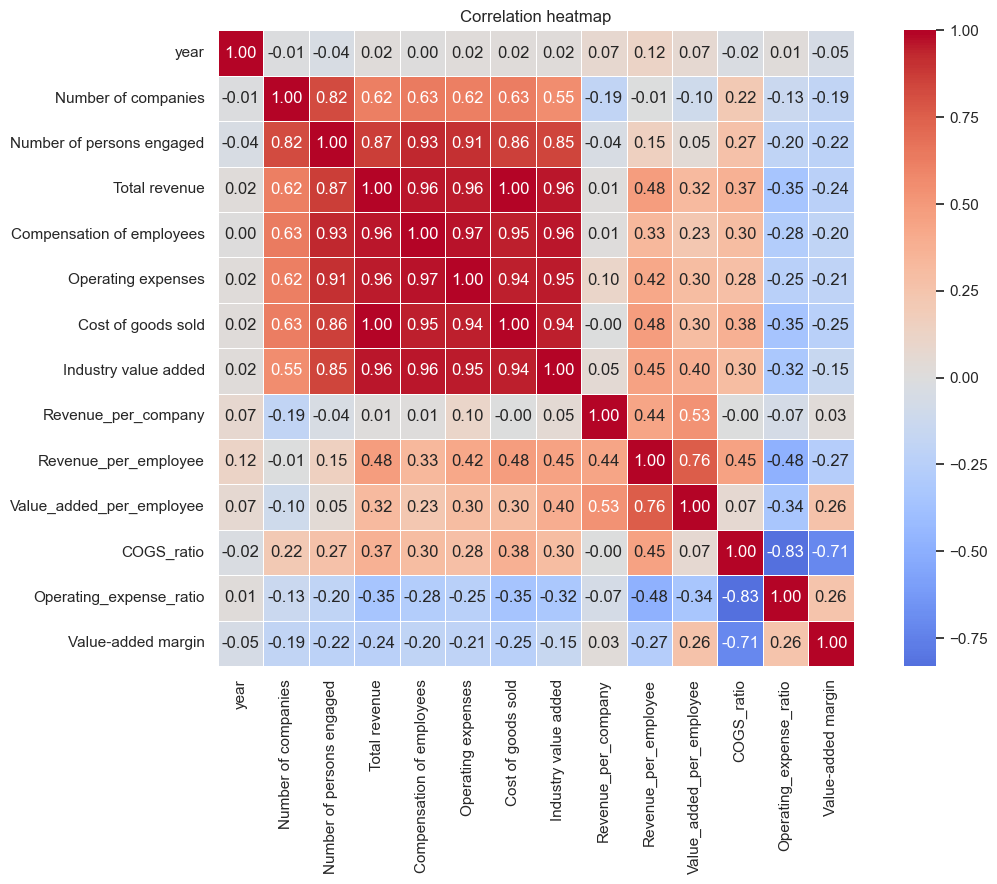

In [602]:

numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [576]:
df['Revenue_per_company'].describe().T

count      545.00
mean       835.47
std      1,581.20
min          0.92
25%         20.55
50%        164.07
75%        763.79
max     10,682.25
Name: Revenue_per_company, dtype: float64

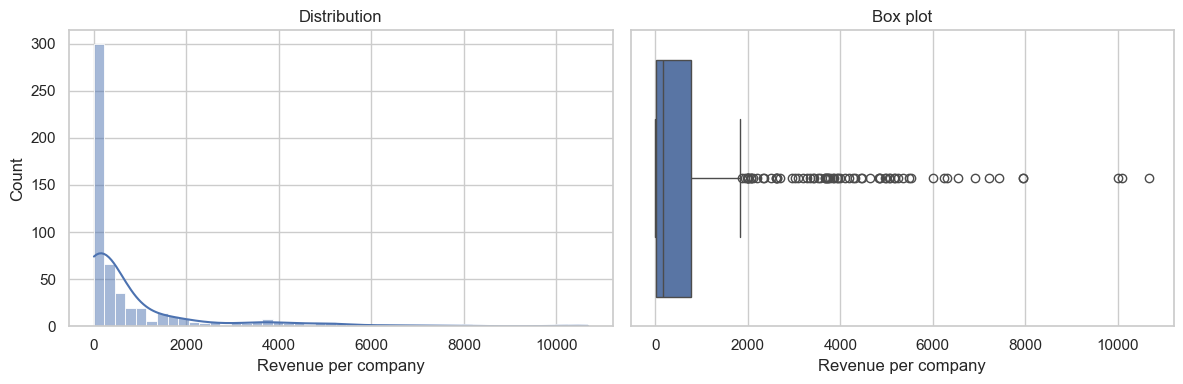

In [577]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(df["Revenue_per_company"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Revenue per company")

# Box plot
sns.boxplot(x=df["Revenue_per_company"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("Revenue per company")

plt.tight_layout()
plt.show()

In [578]:
.max()

SyntaxError: invalid syntax (2836820257.py, line 1)

In [ ]:
df[df["Revenue_per_company"] == df["Revenue_per_company"].max()]

#note that this metric is highly skewed, with very extreme outliers, 
we can see that the outliear is from Other import/export trade from I/E industry, larget scale company, with this information, we can further investiage the dataset based on scale and industry dimension

In [579]:
df['Revenue_per_employee'].describe().T

count   545.00
mean      5.57
std       5.88
min       0.39
25%       1.83
50%       3.57
75%       6.74
max      50.93
Name: Revenue_per_employee, dtype: float64

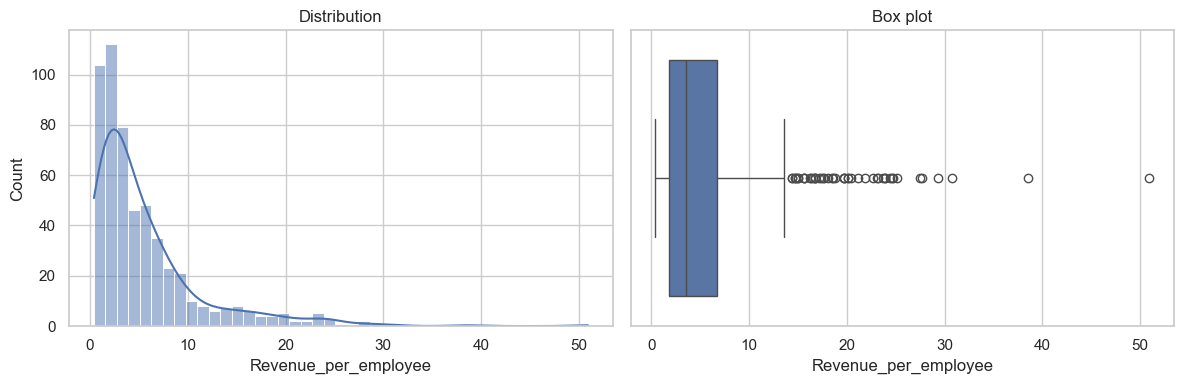

In [580]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(df["Revenue_per_employee"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Revenue_per_employee")

# Box plot
sns.boxplot(x=df["Revenue_per_employee"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("Revenue_per_employee")

plt.tight_layout()
plt.show()

In [581]:
df['Value_added_per_employee'].describe().T

count   545.00
mean      0.70
std       0.69
min      -0.04
25%       0.27
50%       0.44
75%       0.85
max       3.52
Name: Value_added_per_employee, dtype: float64

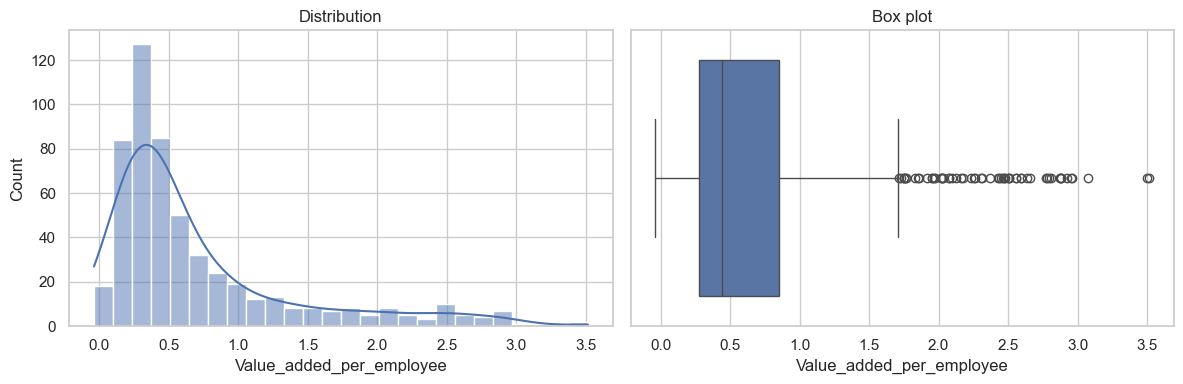

In [582]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(df["Value_added_per_employee"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Value_added_per_employee")

# Box plot
sns.boxplot(x=df["Value_added_per_employee"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("Value_added_per_employee")

plt.tight_layout()
plt.show()

In [583]:
df['COGS_ratio'].describe().T

count   545.00
mean      0.68
std       0.16
min       0.20
25%       0.56
50%       0.69
75%       0.81
max       0.95
Name: COGS_ratio, dtype: float64

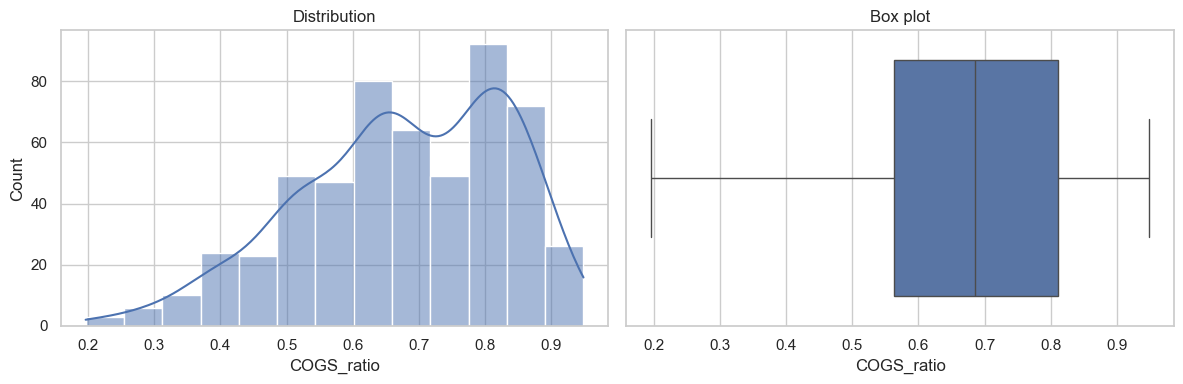

In [584]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(df["COGS_ratio"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("COGS_ratio")

# Box plot
sns.boxplot(x=df["COGS_ratio"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("COGS_ratio")

plt.tight_layout()
plt.show()

In [585]:
df['Operating_expense_ratio'].describe().T

count   545.00
mean      0.16
std       0.10
min       0.02
25%       0.07
50%       0.12
75%       0.22
max       0.52
Name: Operating_expense_ratio, dtype: float64

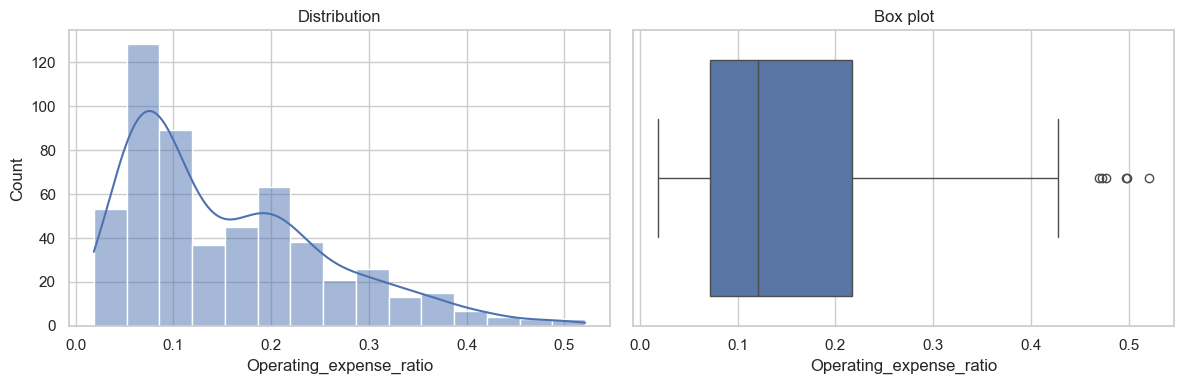

In [586]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(df["Operating_expense_ratio"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Operating_expense_ratio")

# Box plot
sns.boxplot(x=df["Operating_expense_ratio"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("Operating_expense_ratio")

plt.tight_layout()
plt.show()

In [587]:
df['Value-added margin'].describe().T

count   545.00
mean      0.15
std       0.08
min      -0.01
25%       0.10
50%       0.13
75%       0.18
max       0.61
Name: Value-added margin, dtype: float64

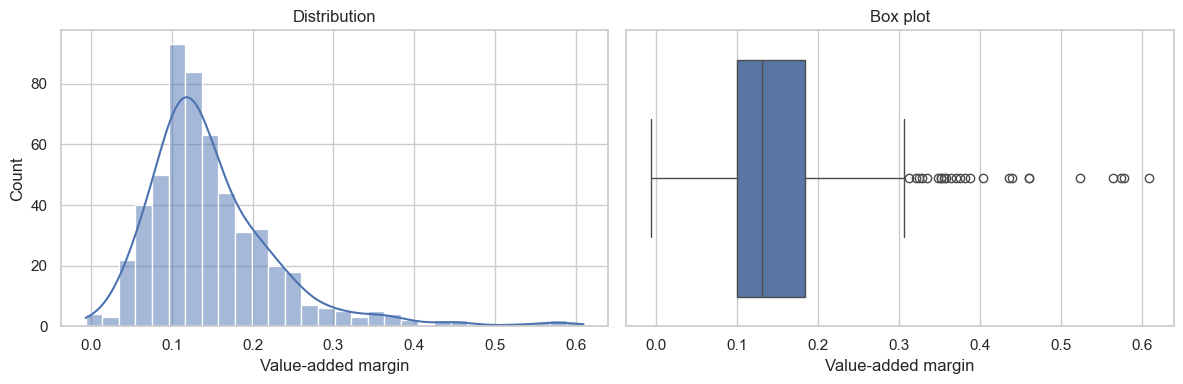

In [588]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(df["Value-added margin"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Value-added margin")

# Box plot
sns.boxplot(x=df["Value-added margin"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("Value-added margin")

plt.tight_layout()
plt.show()

#The World Bank notes that average distribution margins across countries often range between 10% and 15%. A 15% value-added margin places a business at the top of this typical range.

-1B — Distribution by dimension
-

-let filter by parent and child gp first
-

In [589]:
df["Industry Grouping"] = df["Industry Grouping"].str.strip()

In [590]:
parent_groups = [
    'Import/export trade',
    'Wholesale trade',
    'Retail trade'
]

df['Industry_Level'] = df['Industry Grouping'].apply(
    lambda x: 'Parent' if x in parent_groups else 'Child'
)

In [591]:
df['Industry_Level'].value_counts()

Industry_Level
Child     650
Parent    180
Name: count, dtype: int64

In [592]:
df.head()

,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Revenue_per_company,Revenue_per_employee,Value_added_per_employee,COGS_ratio,Operating_expense_ratio,Value-added margin,Industry_Level
0,2015,Import/export trade,< 10,"70,481.00","226,453.00","1,645,381.00","61,651.00","101,888.00","1,383,801.00","155,615.00",23.35,7.27,0.69,0.84,0.06,0.09,Parent
1,2015,Import/export trade,10 - 49,"9,195.00","155,526.00","1,415,865.00","56,875.00","86,202.00","1,183,404.00","140,246.00",153.98,9.10,0.90,0.84,0.06,0.10,Parent
2,2015,Import/export trade,50 - 99,580.00,"36,486.00","343,224.00","16,128.00","27,546.00","275,352.00","39,041.00",591.77,9.41,1.07,0.80,0.08,0.11,Parent
3,2015,Import/export trade,100 - 199,167.00,"23,220.00","274,225.00","11,263.00","31,632.00","181,734.00","52,263.00","1,642.07",11.81,2.25,0.66,0.12,0.19,Parent
4,2015,Import/export trade,200 - 499,70.00,"21,105.00","211,493.00","10,607.00","20,319.00","155,359.00","25,483.00","3,021.33",10.02,1.21,0.73,0.10,0.12,Parent


In [593]:
df[df['Industry_Level'] == 'Parent']['Industry Grouping'].unique()

array(['Import/export trade', 'Wholesale trade', 'Retail trade'],
      dtype=object)

In [594]:
df[df['Industry_Level'] == 'Child']['Industry Grouping'].unique()

array(['Food, alcoholic drinks and tobacco_I/E',
       'Clothing, footwear and allied products_I/E',
       'Other import/export trade_I/E',
       'Food, alcoholic drinks and tobacco_W',
       'Clothing, footwear and allied products_W',
       'Other wholesale trade_W', 'Food, alcoholic drinks and tobacco_R',
       'Fuel_R', 'Clothing, footwear and allied products_R',
       'Transport equipment_R', 'Other retail trade_R'], dtype=object)

In [595]:
parent_df = df[df['Industry_Level'] == 'Parent'].copy().reset_index()
child_df = df[df['Industry_Level'] == 'Child'].copy().reset_index()

In [596]:
parent_df[:50]

,index,year,Industry Grouping,scale_band,Number of companies,Number of persons engaged,Total revenue,Compensation of employees,Operating expenses,Cost of goods sold,Industry value added,Revenue_per_company,Revenue_per_employee,Value_added_per_employee,COGS_ratio,Operating_expense_ratio,Value-added margin,Industry_Level
0,0,2015,Import/export trade,< 10,"70,481.00","226,453.00","1,645,381.00","61,651.00","101,888.00","1,383,801.00","155,615.00",23.35,7.27,0.69,0.84,0.06,0.09,Parent
1,1,2015,Import/export trade,10 - 49,"9,195.00","155,526.00","1,415,865.00","56,875.00","86,202.00","1,183,404.00","140,246.00",153.98,9.10,0.90,0.84,0.06,0.10,Parent
2,2,2015,Import/export trade,50 - 99,580.00,"36,486.00","343,224.00","16,128.00","27,546.00","275,352.00","39,041.00",591.77,9.41,1.07,0.80,0.08,0.11,Parent
3,3,2015,Import/export trade,100 - 199,167.00,"23,220.00","274,225.00","11,263.00","31,632.00","181,734.00","52,263.00","1,642.07",11.81,2.25,0.66,0.12,0.19,Parent
4,4,2015,Import/export trade,200 - 499,70.00,"21,105.00","211,493.00","10,607.00","20,319.00","155,359.00","25,483.00","3,021.33",10.02,1.21,0.73,0.10,0.12,Parent
5,5,2015,Import/export trade,≥ 500,19.00,"16,280.00","70,901.00","6,647.00","13,740.00","40,132.00","14,018.00","3,731.63",4.36,0.86,0.57,0.19,0.20,Parent
6,24,2015,Wholesale trade,< 10,"12,748.00","36,061.00","166,188.00","5,722.00","7,561.00","149,243.00","9,589.00",13.04,4.61,0.27,0.90,0.05,0.06,Parent
7,25,2015,Wholesale trade,10 - 49,"1,003.00","18,180.00","89,679.00","4,350.00","3,710.00","78,888.00","6,861.00",89.41,4.93,0.38,0.88,0.04,0.08,Parent
8,26,2015,Wholesale trade,50 - 99,55.00,"3,684.00","16,131.00",998.00,"1,114.00","13,095.00","1,913.00",293.29,4.38,0.52,0.81,0.07,0.12,Parent
9,27,2015,Wholesale trade,100 - 199,17.00,"2,186.00","20,974.00",713.00,"1,049.00","18,452.00","1,466.00","1,233.76",9.59,0.67,0.88,0.05,0.07,Parent


-1B — parent gp (Industry band)
-

     Industry Grouping  Total revenue
0  Import/export trade  40,326,930.00
1         Retail trade   4,773,445.00
2      Wholesale trade   2,849,647.00


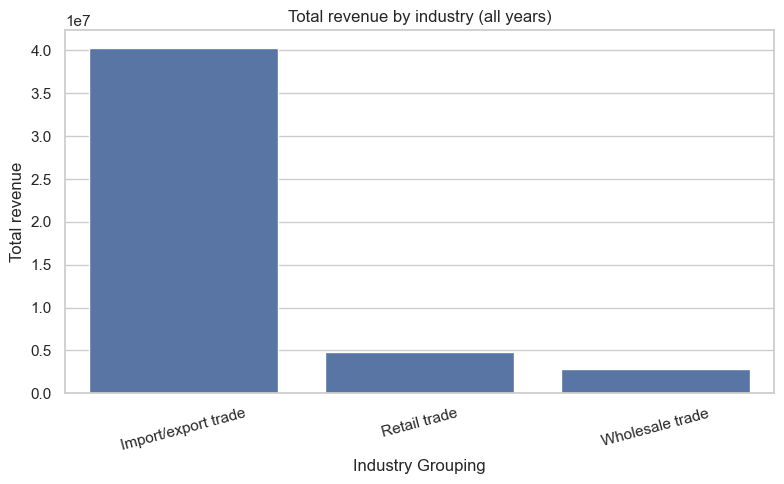

In [597]:
total_by_ind = (parent_df.groupby("Industry Grouping", as_index=False)
                  ["Total revenue"].sum()
                  .sort_values("Total revenue", ascending=False))

print(total_by_ind)

plt.figure(figsize=(8, 5))
sns.barplot(data=total_by_ind, x="Industry Grouping", y="Total revenue")
plt.title("Total revenue by industry (all years)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

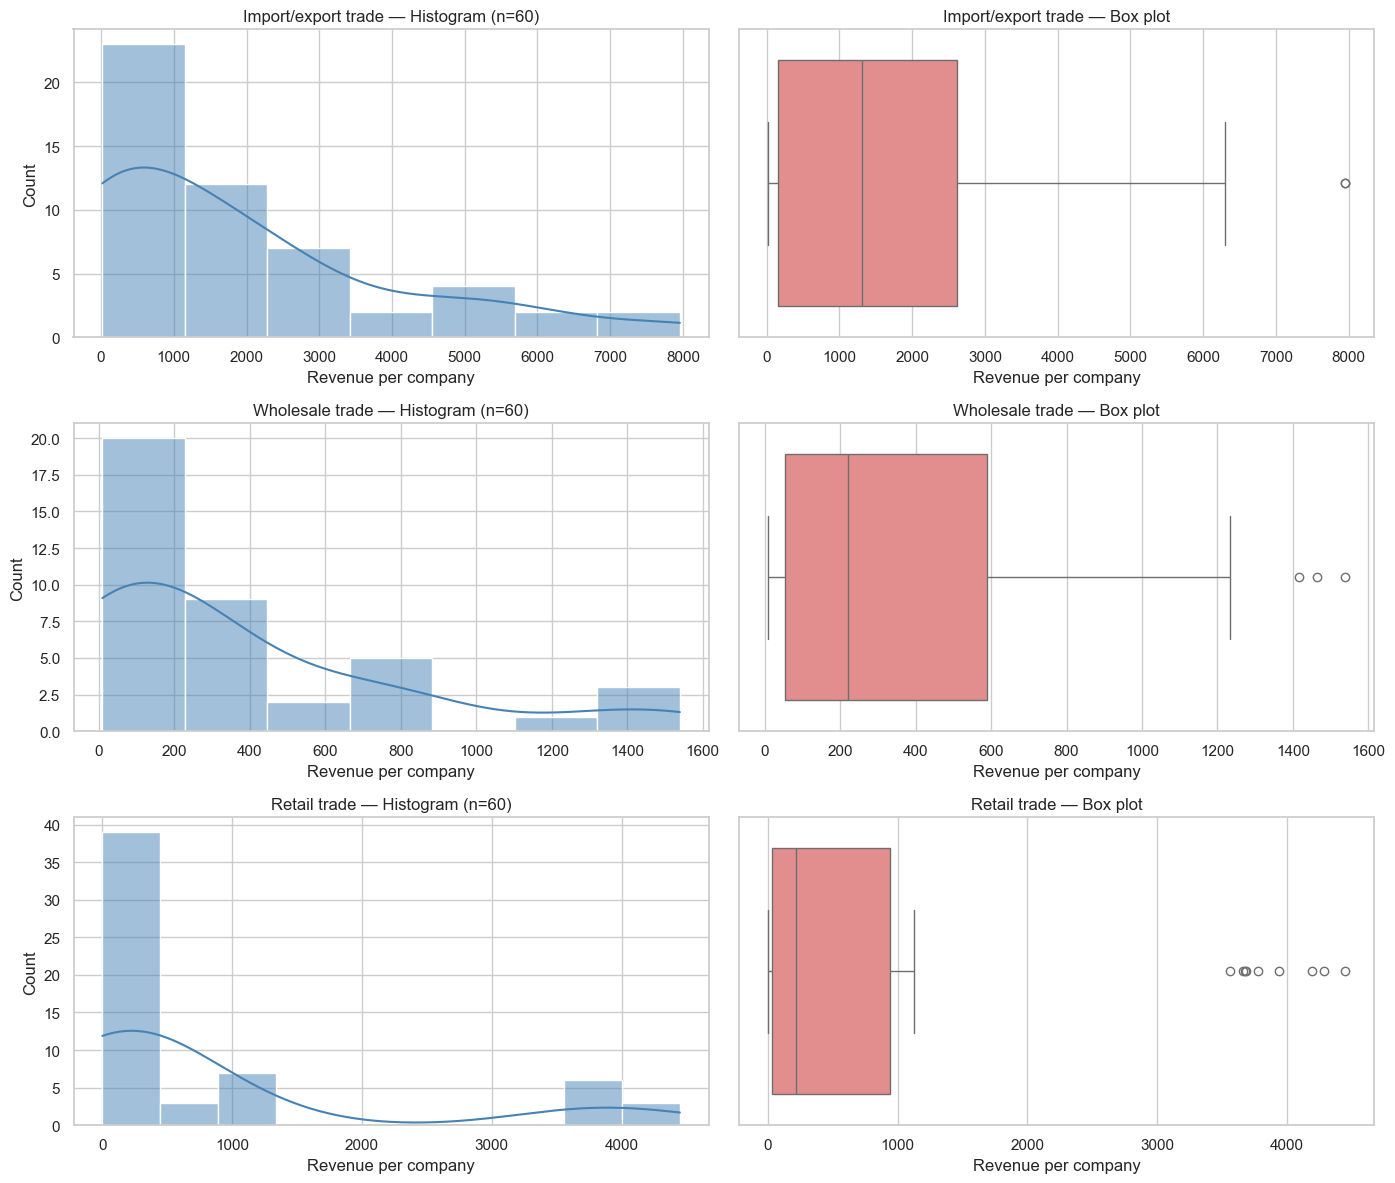

In [598]:
sns.set_style("whitegrid")
industries = parent_df["Industry Grouping"].unique()

fig, axes = plt.subplots(len(industries), 2,
                         figsize=(14, 4 * len(industries)))

for i, ind in enumerate(industries):
    subset = parent_df.loc[parent_df["Industry Grouping"] == ind,
                    "Revenue_per_company"]

    # Histogram + KDE
    sns.histplot(subset, kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"{ind} — Histogram (n={len(subset)})")
    axes[i, 0].set_xlabel("Revenue per company")

    # Box plot
    sns.boxplot(x=subset, ax=axes[i, 1], color="lightcoral")
    axes[i, 1].set_title(f"{ind} — Box plot")
    axes[i, 1].set_xlabel("Revenue per company")

plt.tight_layout()
plt.show()

noticed that since the industry is greatly contributed by small scale of company (<50), which has limited profit generation ability, so the revenue per company tend to be right-skwed here. Also, Import/export operates on the largest revenue scale (up to ~8,000), followed by Retail (up to ~5,000), and Wholesale operates on the smallest scale (up to ~1,500).

In [599]:
parent_df['Revenue_per_company'].describe().T

count     150.00
mean    1,085.53
std     1,650.01
min         1.56
25%        40.23
50%       316.16
75%     1,341.34
max     7,957.24
Name: Revenue_per_company, dtype: float64

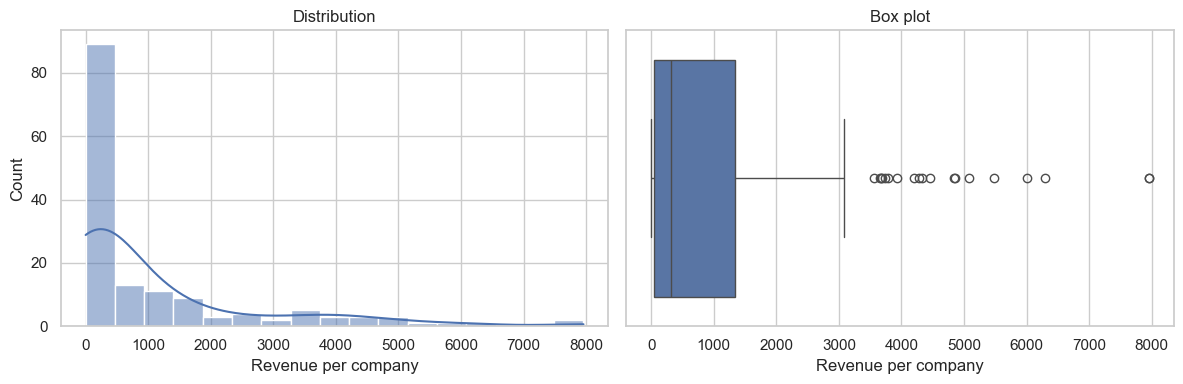

In [600]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
sns.histplot(parent_df["Revenue_per_company"], kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Revenue per company")

# Box plot
sns.boxplot(x=parent_df["Revenue_per_company"], ax=axes[1])
axes[1].set_title("Box plot")
axes[1].set_xlabel("Revenue per company")

plt.tight_layout()
plt.show()

# 26. CONSTRUCT — Tableau Dashboard Blueprint

## Dashboard 1 — Executive Overview

Show:
- Total receipts
- Industry value added
- Persons engaged
- Number of companies
- 2015–2024 trend
- Import/export vs wholesale vs retail

## Dashboard 2 — Trade Activity Performance

Compare:
- Import/export
- Wholesale
- Retail

KPIs:
- receipts;
- value added;
- persons engaged;
- receipts/person;
- value added/person.

Filters:
- year;
- company size.

## Dashboard 3 — Product / Business Category

Use the hierarchy:

**Trade activity → Product category**

For example:

> Retail → Food

rather than simply:

> Food

This prevents mixing different business activities.

## Dashboard 4 — Company Size & Efficiency

Compare:
- <10
- 10–49
- 50–99
- 100–199
- 200–499
- ≥500

Show:
- receipts/person;
- value added/person;
- workforce;
- receipts.

## Dashboard 5 — COVID / Recovery

Clearly annotate:

**2021–2022: reported figures include anti-epidemic subsidies.**


# 27. EVALUATE — Data Quality Checklist

Before publishing:

- [ ] Raw file preserved
- [ ] Multi-row header reconstructed correctly
- [ ] Years mapped correctly
- [ ] Seven measures mapped correctly
- [ ] `*` treated as missing, not zero
- [ ] No duplicate analytical keys
- [ ] Parent/child hierarchy preserved
- [ ] Grand Total not mixed into segment aggregation
- [ ] Company-size groups preserved
- [ ] Units checked
- [ ] COVID/subsidy caveat documented


# 28. EVALUATE — Analytical Quality Checklist

- [ ] Every KPI has a clear definition
- [ ] Parent + child double counting avoided
- [ ] Percentage growth is not used alone for tiny segments
- [ ] Correlation is not described as causation
- [ ] Receipts/person is not called profit
- [ ] Value added is not called profit
- [ ] Suppressed values are not treated as zero
- [ ] COVID/subsidy period is qualified
- [ ] Findings contain specific evidence


# 29. EVALUATE — Final Reflection

Answer these before calling the project finished:

1. What was the original business problem?
2. What was the most important finding?
3. What was the most surprising finding?
4. Which finding could plausibly support a business decision?
5. What can this dataset **not** tell us?
6. What additional data would you request from the stakeholder?
7. What would you analyze next if you had another month?

A strong analyst does not only explain what the data says.

They also explain **what the data cannot say**.


# Final Deliverables

Your portfolio should contain:

### 1. Python notebook
`HK_Trading_Business_Analysis.ipynb`

### 2. Clean Tableau dataset
`hk_trading_business_analysis_tableau.csv`

### 3. Tableau workbook
`HK_Trading_Business_Performance.twbx`

### 4. GitHub README

Include:
- business problem;
- data source;
- data grain;
- hierarchy;
- cleaning;
- KPI definitions;
- key findings;
- limitations;
- Tableau screenshots.

---

## Recommended portfolio positioning

> **Hong Kong Trading Industry Performance & Business Efficiency Analysis (2015–2024)**  
> Cleaned and analyzed official Hong Kong business statistics using Python, developed business-efficiency KPIs across trade activity, product category and company size, and translated the findings into an interactive Tableau dashboard.
